In [1]:
# Внимание!!! Важно, что бы файлы с данными и исполняемый файл находились в одной папке, 
# тогда пути к тестовым и тренировочным наборам будут содержать только имена файлов.
# 
# В пути к тренировочным и тестовым данным запрежается использовать абсалютную адресацию, 
# то есть адресацию, в которой присутствуют имена папок. Путь должен содержать только имя файла.
#
# Напоминание: под моделью машинного обучения понимаются все действия с исходными данными, 
# которые необходимо произвести, что бы сопоставить признаки целевому значению.

### Область работы 1 (библиотеки)

In [2]:
# Данный блок в области 1 НЕ выполняется преподавателем
# 
# данный блок предназначен только для подключения необходимых библиотек
# запрещается подключать библиотеки в других блоках
#
# установка дополнительных библиотек размещается прямо здесь (обязательно закоментированы)
#
#!pip install catboost

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import category_encoders as ce

from IPython.display import display
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib

from sklearn.datasets import load_iris

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, TransformedTargetRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.model_selection import FixedThresholdClassifier

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import Lars, OrthogonalMatchingPursuit, SGDRegressor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.feature_selection import SequentialFeatureSelector, RFECV

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import make_scorer

print(sklearn.__version__)


1.7.2


### Область работы 2 (поиск  модели .... )

In [4]:
# Данный блок(и) НЕ выполняются преподавателем в области 2
# блок(и) предназначены для поиска лучшей модели 
# должен быть понятен и очевиден отбор параметров модели
# 
# Запрещается размещать данные блоки за пределами обасти 2
# Все блоки данной области должны быть выполнены
#
# ЗАПРЕЩАЕТСЯ ИСПОЛЬЗОВАТЬ ТЕСТОВЫЙ НАБОР
#
# Путь к тренировочному набору
# 

path_train = 'train.csv' # содержит только имя файла, без имен папок !!!

Загружаем данные и смотрим на них

In [5]:
df = pd.read_csv(path_train)

In [6]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,2,18,2,6,1239,5,3,4,3,1,...,4,61,3,3,1,3,2,1,2,1
1,1,30,0,9,8072,5,2,2,3,1,...,3,25,1,2,3,3,2,1,2,1
2,4,27,3,1,8613,4,3,2,3,1,...,3,27,3,2,2,3,2,1,2,1
3,4,9,2,4,1236,1,2,1,2,1,...,1,23,3,1,1,3,2,2,2,1
4,1,6,4,0,4716,5,2,1,3,1,...,1,44,3,2,2,2,1,1,2,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   750 non-null    int64
 1   duration                 750 non-null    int64
 2   credit_history           750 non-null    int64
 3   purpose                  750 non-null    int64
 4   amount                   750 non-null    int64
 5   savings                  750 non-null    int64
 6   employment_duration      750 non-null    int64
 7   installment_rate         750 non-null    int64
 8   personal_status_sex      750 non-null    int64
 9   other_debtors            750 non-null    int64
 10  present_residence        750 non-null    int64
 11  property                 750 non-null    int64
 12  age                      750 non-null    int64
 13  other_installment_plans  750 non-null    int64
 14  housing                  750 non-null    int64
 15  number

In [8]:
df.describe()


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,750.00000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,...,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,2.54400,21.058667,2.525333,2.873333,3315.892000,2.113333,3.382667,2.977333,2.689333,1.158667,...,2.348000,35.305333,2.669333,1.934667,1.414667,2.890667,1.849333,1.410667,1.964000,0.700000
std,1.24772,12.152866,1.095578,2.783455,2887.629212,1.587403,1.216912,1.102621,0.712856,0.501158,...,1.050254,11.230150,0.710398,0.521627,0.589221,0.662796,0.357962,0.492283,0.186414,0.458563
min,1.00000,4.000000,0.000000,0.000000,250.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.00000,12.000000,2.000000,1.000000,1373.250000,1.000000,3.000000,2.000000,2.000000,1.000000,...,1.000000,27.000000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.00000,18.000000,2.000000,2.000000,2330.000000,1.000000,3.000000,3.000000,3.000000,1.000000,...,2.000000,33.000000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.00000,24.000000,4.000000,3.000000,3975.250000,3.000000,5.000000,4.000000,3.000000,1.000000,...,3.000000,42.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.00000,72.000000,4.000000,10.000000,18424.000000,5.000000,5.000000,4.000000,4.000000,3.000000,...,4.000000,75.000000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


In [9]:
df.duplicated().unique()

array([False])

<Axes: >

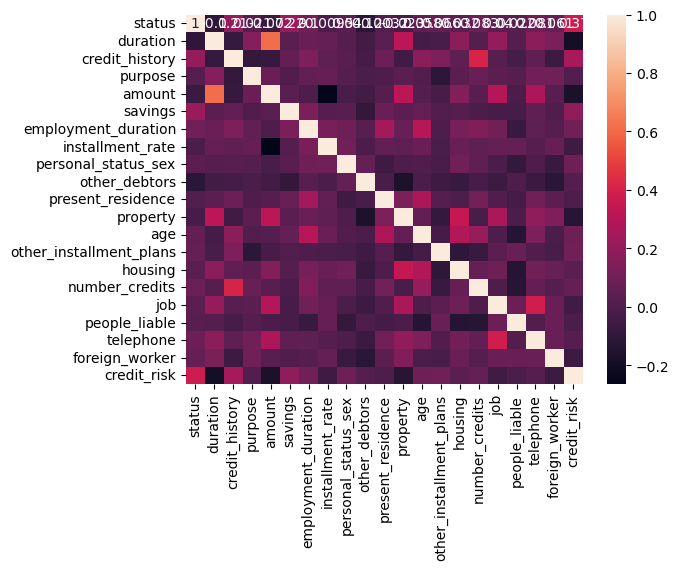

In [10]:
sns.heatmap(df.corr(), annot=True)

Оптимально признаков: 19

Отобранные признаки:
['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone']

Отброшенные признаки:
['foreign_worker']


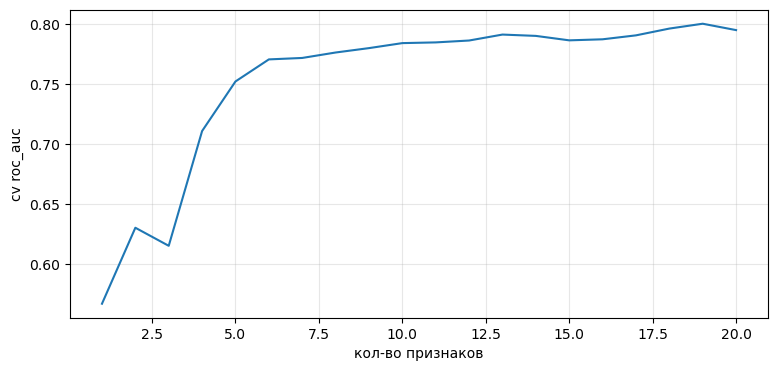

In [11]:
X = df.drop(columns = ['credit_risk'])
y = df['credit_risk']
features = X.columns.tolist()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

est = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
)

rfecv = RFECV(
    estimator=est,
    step=1,
    cv=cv,
    scoring="roc_auc",
    min_features_to_select=1,
    n_jobs=-1
)

rfecv.fit(X, y)

mask = rfecv.support_
selected = [f for f, m in zip(features, mask) if m]
dropped  = [f for f, m in zip(features, mask) if not m]

print("Оптимально признаков:", rfecv.n_features_)
print("\nОтобранные признаки:")
print(selected)

print("\nОтброшенные признаки:")
print(dropped)


res = rfecv.cv_results_
x = res["n_features"]

plt.figure(figsize=(9, 4))
plt.plot(x, res["mean_test_score"])
plt.xlabel("кол-во признаков")
plt.ylabel("cv roc_auc")
plt.grid(True, alpha=0.3)
plt.show()

По итогу отбора признаков при помощью RFECV отбрасываем один признак - foreign_worker

In [12]:
y = np.array(df.credit_risk)
X = df.drop(columns=['credit_risk','foreign_worker'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=150,
    random_state=42, 
)

In [13]:
num_features = ['age', 'duration', 'amount']

In [14]:
cat_features = ['status', 'credit_history', 'purpose', 'savings', 'installment_rate',
       'other_debtors', 'present_residence',
       'other_installment_plans', 'housing', 'number_credits', 'job',
       'people_liable', 'telephone']

# Осуществляем предобработку при помощи колумн трансформеров
## Для числовых фичей используем: 
 - преобразование Йео-Джонсона, обеспечивающее нормальность данных
 - полиномиальный фичинг для учета возможных нелинейностей связей
 - StandardScaler() для стандартизации данных (приведения их к одной размерности)
   
Для категориальных фичей достаточно только стандартизации с помощью все того же StandardScaler()

In [15]:
num_transformer = Pipeline(steps=[
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(
        degree=3,
        include_bias=False
    ))
])

cat_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

CT = ColumnTransformer([
    ("num_transformer", num_transformer, num_features),
    ("cat_transformer", cat_transformer, cat_features)
]).set_output(transform='pandas')

display(CT)
ct = CT.fit_transform(X_train)
pd.DataFrame(ct).head().T

,transformers,"[('num_transformer', ...), ('cat_transformer', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,method,'yeo-johnson'
,standardize,True
,copy,True


,595,131,44,70,672
num_transformer__age,-1.202266,0.043904,-0.710302,-0.430038,-5.659989e-01
num_transformer__duration,2.448004,-1.793199,-0.686618,-0.686618,-3.583545e-03
num_transformer__amount,1.046809,-0.550131,-1.196521,-0.995679,-1.108737e-01
num_transformer__age^2,1.445445,0.001928,0.504529,0.184933,3.203547e-01
num_transformer__age duration,-2.943153,-0.078728,0.487706,0.295272,2.028283e-03
num_transformer__age amount,-1.258543,-0.024153,0.849891,0.428180,6.275438e-02
num_transformer__duration^2,5.992723,3.215563,0.471445,0.471445,1.284180e-05
num_transformer__duration amount,2.562591,0.986494,0.821553,0.683651,3.973209e-04
num_transformer__amount^2,1.095808,0.302644,1.431663,0.991376,1.229297e-02
num_transformer__age^3,-1.737809,0.000085,-0.358368,-0.079528,-1.813204e-01


Целевая метрика: сумма FP и FN, которую необходимо минимизировать.  
Для решения задачи используется градиентный бустинг, при настройке которого особое внимание уделено контролю сложности модели и снижению риска переобучения:

- **`n_estimators = 4000`** — максимальное количество деревьев. Значение выбрано заведомо большим, так как далее используется механизм ранней остановки (*early stopping*): модель автоматически прекратит обучение, если качество на валидационной выборке перестанет улучшаться. Это позволяет не ограничивать модель искусственно малым числом итераций.

- **`learning_rate = 0.05`** — скорость обучения. Умеренно малое значение делает вклад каждого дерева менее агрессивным, обучение более стабильным и снижает риск переобучения. Компенсируется увеличенным числом деревьев.

- **`max_depth = 1`** — максимальная глубина деревьев. Используются очень простые деревья (decision stumps), что является сильной формой регуляризации и предотвращает подгонку под шум в данных.

- **`min_samples_leaf = 10`** — минимальное количество наблюдений в листе. Запрещает формирование листьев на редких и шумных наблюдениях, делая разбиения более устойчивыми.

- **`min_samples_split = 30`** — минимальное количество объектов, необходимое для разбиения узла. Дополнительно ограничивает сложность деревьев и предотвращает излишне детальные разбиения.

- **`subsample = 0.8`** — доля обучающей выборки, используемая при построении каждого дерева. Вводит стохастичность в процесс обучения, снижает корреляцию между деревьями и уменьшает переобучение.

- **`random_state = 42`** — фиксирует генератор случайных чисел для воспроизводимости результатов.

- **`validation_fraction = 0.3`** — доля обучающей выборки, автоматически выделяемая под внутреннюю валидацию для реализации ранней остановки.

- **`n_iter_no_change = 30`** — количество итераций без улучшения качества на валидации, после которых обучение прекращается. Позволяет модели дойти до возможных улучшений, но не переобучаться.

- **`tol = 1e-4`** — минимальный порог улучшения метрики, считающийся значимым. Используется для игнорирования шумовых колебаний качества при ранней остановке.


In [16]:
pipe_gb = Pipeline([
    ('preprocesing', CT),
    ('ml', GradientBoostingClassifier(
        n_estimators=4000,       
        learning_rate=0.05,      
        max_depth=1,             
        min_samples_leaf=10,     
        min_samples_split=30,
        subsample=0.8,           
        random_state=42,
        validation_fraction=0.3,   
        n_iter_no_change=30,        
        tol=1e-4
    ))])

pipe_gb.fit(X_train, y_train)
y_pred = pipe_gb.predict(X_test)


y_pred_train = pipe_gb.predict(X_train)

print("TRAIN accuracy:", accuracy_score(y_train, y_pred_train))
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
print("TRAIN FP + FN =", fp_tr + fn_tr)




y_pred_test = pipe_gb.predict(X_test)

print("TEST accuracy:", accuracy_score(y_test, y_pred_test))
tn_te, fp_te, fn_te, tp_te = confusion_matrix(y_test, y_pred_test).ravel()
print("TEST FP + FN =", fp_te + fn_te)


TRAIN accuracy: 0.8033333333333333
TRAIN FP + FN = 118
TEST accuracy: 0.78
TEST FP + FN = 33


Заметим, что различие метрик на трейне и на тесте минимально - модель не переобучена и может быть использована в качестве финальной